In [275]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


In [276]:
import numpy as np
from numpy import array 

w1_X=[array([0.828282, 0.777777]), array([0.737803, 0.601555]), array([8.86456e-01, 4.04712e-01, 9.80000e-05]), array([0.429578, 0.400818, 0.067425, 0.12233 ]), array([0.361593, 0.858022, 0.999172, 0.995663]), array([0.315938, 0.017065, 0.899154, 0.923548, 0.050946]), array([0.01693 , 0.900096, 0.826978, 0.174167, 0.413273, 0.770548]), array([0.037897, 0.017931, 0.035032, 0.225387, 0.022555, 0.624348,
       0.009878, 0.901238])]

w1_X

[array([0.828282, 0.777777]),
 array([0.737803, 0.601555]),
 array([8.86456e-01, 4.04712e-01, 9.80000e-05]),
 array([0.429578, 0.400818, 0.067425, 0.12233 ]),
 array([0.361593, 0.858022, 0.999172, 0.995663]),
 array([0.315938, 0.017065, 0.899154, 0.923548, 0.050946]),
 array([0.01693 , 0.900096, 0.826978, 0.174167, 0.413273, 0.770548]),
 array([0.037897, 0.017931, 0.035032, 0.225387, 0.022555, 0.624348,
        0.009878, 0.901238])]

In [277]:
# w1_X=[array([0.828282, 0.777777]), array([0.737803, 0.601555]), array([8.86456e-01, 4.04712e-01, 9.80000e-05]), array([0.429578, 0.400818, 0.067425, 0.12233 ]), array([0.361593, 0.858022, 0.999172, 0.995663]), array([0.315938, 0.017065, 0.899154, 0.923548, 0.050946]), array([0.01693 , 0.900096, 0.826978, 0.174167, 0.413273, 0.770548]), array([0.037897, 0.017931, 0.035032, 0.225387, 0.022555, 0.624348,
#        0.009878, 0.901238])]

w1_y=[np.float64(-1.6268381341133806e-44), np.float64(0.4928057580204476), np.float64(-0.132677666460545), np.float64(-10.018190081663906), np.float64(2986.9195108234217), np.float64(-0.9319781034031738), np.float64(0.20988115645652092), np.float64(9.5430642790311)]
w1_y


[-1.6268381341133806e-44,
 0.4928057580204476,
 -0.132677666460545,
 -10.018190081663906,
 2986.9195108234217,
 -0.9319781034031738,
 0.20988115645652092,
 9.5430642790311]

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. 
# Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
# To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. 
# It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

week1_X = [0.737803, 0.601555]
week1_y = 0.4928057580204476

X = np.vstack([X, week1_X])
y = np.append(y, week1_y)

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

-- inputs X ---
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.737803   0.601555  ]]
X shape= (11, 2)
-- outputs y ---
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.49280576]
y shape= (11,)


In [279]:
df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

# Week1 result is in 3rd Place 
# 10	0.737803	0.601555	0.492806


,x1,x2,y
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
10,0.737803,0.601555,0.492806
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993
6,0.438166,0.685018,0.244619
4,0.454647,0.290455,0.214965
7,0.341750,0.028698,0.038749
5,0.577713,0.771973,0.023106
8,0.338648,0.213867,-0.013858


In [280]:
sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

print(sorted_idx)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

[ 9  0 10  1  3  6  4  7  5  8  2]
Current Best x_idx: 9
Current Best x: [0.70263656 0.9265642 ]
Current Best y: 0.6112052157614438
Current 2nd Best x: [0.66579958 0.12396913], y:0.5389961189269181
Current 3nd Best x: [0.737803 0.601555], y:0.4928057580204476


In [281]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# week1
# kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5], 
#                                       length_scale_bounds=(1e-3, 1e5), 
#                                       nu=2.5)
# gp = GaussianProcessRegressor(kernel=kernel, alpha=0.2, normalize_y=True, n_restarts_optimizer=10)

# week2
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5], 
                                      # length_scale_bounds=(1e-3, 1e5), 
                                      # Give some importance to X1
                                      length_scale_bounds=(0.05, 1.5), 
                                      nu=2.5) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-3, 1e-2))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)

gp.fit(X, y)


print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Week1
# Optimized Kernel: 0.963**2 * Matern(length_scale=[0.0597, 2], nu=2.5)
# Training R^2 Score: 0.9952885628437214
# Total variance accounted for as noise: 0.05

# week2
# Optimized Kernel: 0.947**2 * Matern(length_scale=[0.0618, 1.5], nu=2.5) + WhiteKernel(noise_level=0.00792)
# Training R^2 Score: 0.9995614690801788
# Total variance accounted for as noise: 1e-10

Optimized Kernel: 0.947**2 * Matern(length_scale=[0.0618, 1.5], nu=2.5) + WhiteKernel(noise_level=0.00792)
Training R^2 Score: 0.999561470517483
Total variance accounted for as noise: 1e-10


In [282]:
# Create grid of potential X values
res=200
x_coord = np.linspace(0, 1, 200)
X1, X2 = np.meshgrid(x_coord, x_coord)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Get predictions
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)



In [283]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")

# best combination so far 
#     x1      x2          y
# 0.702637	0.926564	0.611205
# Suggested next: 
#     x1          x2         
# [0.71717172 0.        ]

# Submit UCB

UCB Score with kappa: 2.0
Current Best x: [0.70263656 0.9265642 ]
Current Best y: 0.6112052157614438
Suggested next: [0.70351759 0.        ]


In [284]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far 
#     x1      x2          y
# 0.702637	0.926564	0.611205
# Suggested next: 
#     x1          x2  
# [0.70707071 0.        ]

expected_improvement with xi: 0.01
Current Best x: [0.70263656 0.9265642 ]
Current Best y: 0.6112052157614438
Suggested next: [0.69849246 0.31658291]


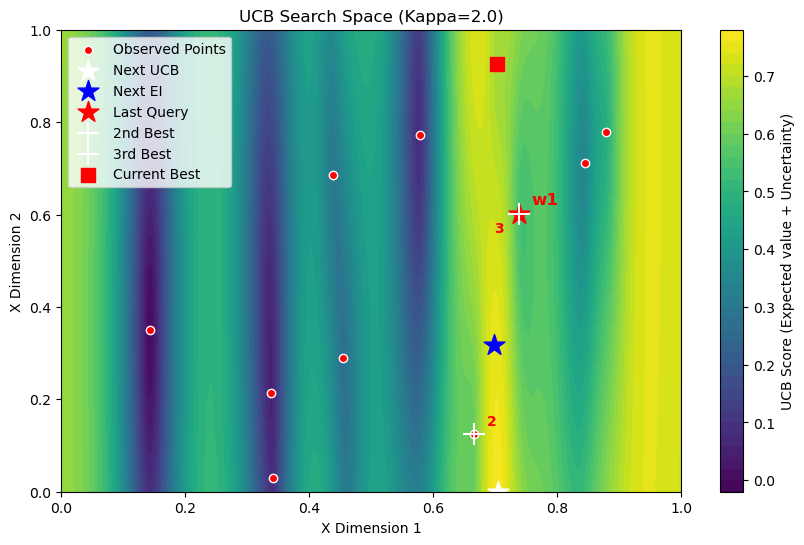

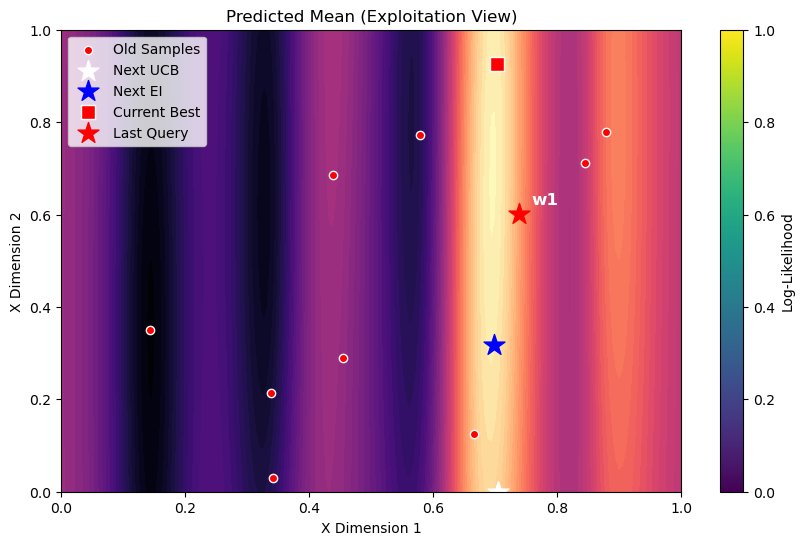

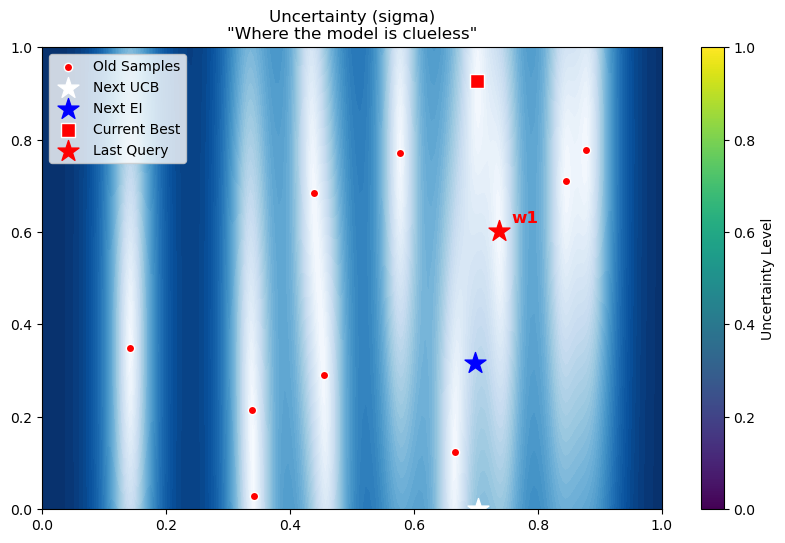

In [285]:
# VISUALIZATION
ucb_map = ucb_values.reshape(res, res)
week1_query= week1_X

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ucb_map, levels=50, cmap='viridis')
plt.colorbar(label='UCB Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
plt.scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')

plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', marker='s', s=100, label='Current Best')
plt.title(f"UCB Search Space (Kappa={kappa})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

mu_map = mu.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, mu_map, levels=50, cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
plt.scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='white')

plt.title('Predicted Mean (Exploitation View)')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

sigma_map = sigma.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, sigma_map, levels=50, cmap='Blues')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
plt.scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.title('Uncertainty (sigma)\n"Where the model is clueless"')
plt.colorbar(label='Uncertainty Level')
plt.legend()
plt.show()

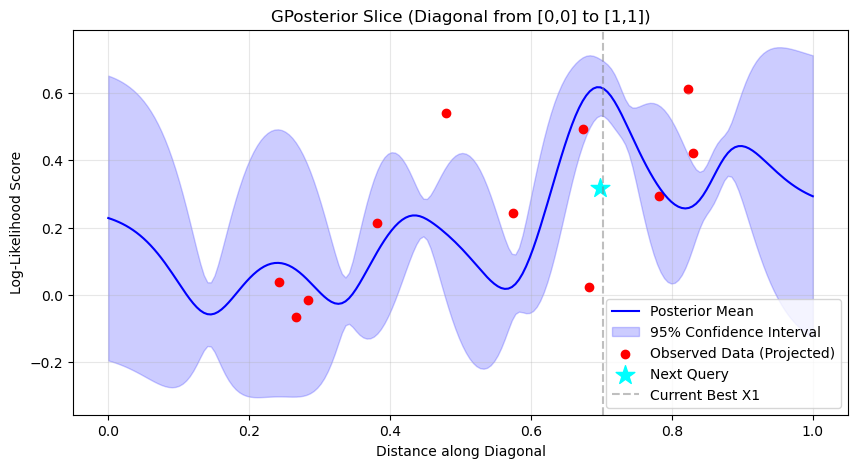

In [286]:
# Create a diagonal slice from [0,0] to [1,1]
n_points = 200
line_coords = np.linspace(0, 1, n_points)
X_slice = np.c_[line_coords, line_coords] # Diagonal slice

# next_query = ucb_next_query
next_query = ei_next_query
# Get mean and standard deviation from the Posterior
mu, sigma = gp.predict(X_slice, return_std=True)

plt.figure(figsize=(10, 5))

# Plot the Mean prediction
plt.plot(line_coords, mu, 'b-', label='Posterior Mean')

# Plot the Confidence Interval (95% confidence = 1.96 * sigma)
plt.fill_between(line_coords, mu - 1.96*sigma, mu + 1.96*sigma, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

# Project existing data points onto this diagonal (for visualization)
# We calculate their distance from [0,0] to place them on the X-axis
dist = np.sqrt(np.sum(X**2, axis=1)) / np.sqrt(2)
plt.scatter(dist, y, c='red', label='Observed Data (Projected)')
plt.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, label='Next Query')
plt.axvline(x=0.702, color='grey', linestyle='--', alpha=0.5, label='Current Best X1')


plt.title('GPosterior Slice (Diagonal from [0,0] to [1,1])')
plt.xlabel('Distance along Diagonal')
plt.ylabel('Log-Likelihood Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

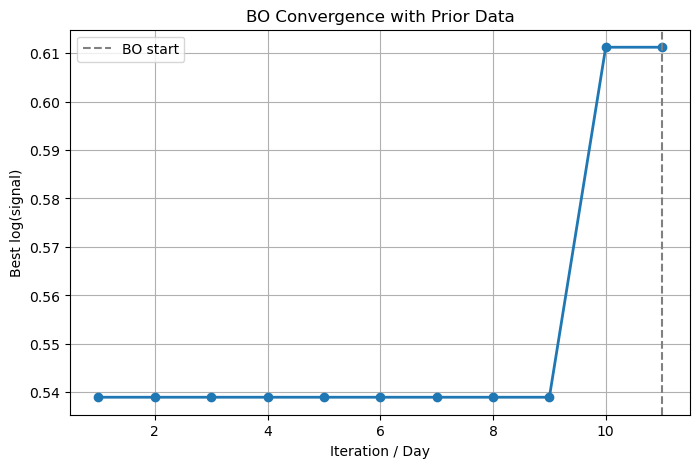

In [287]:
y_observed = y

iterations = np.arange(1, len(y_observed) + 1)
bo_best_y = np.maximum.accumulate(y_observed)

bo_start_idx = 10  # zero-based index of first BO point

plt.figure(figsize=(8,5))
plt.plot(iterations, bo_best_y, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

plt.xlabel("Iteration / Day")
plt.ylabel("Best log(signal)")
plt.title("BO Convergence with Prior Data")
plt.grid(True)
plt.legend()

plt.show()



In [288]:
# Observation 
# Week1 result is in 3rd Place 
# 10	0.737803	0.601555	0.492806

# Week2
# Done this week
#
# - Replace alpha setting with whitekernelnose to do ADR search on noise
# - X2 scale is reduce to give some importance 
# It is now searching in bottom corner of tne next X1 band

# Verdict: 
# UCB Score with kappa: 2.0
# Current Best x: [0.70263656 0.9265642 ]
# Current Best y: 0.6112052157614438
# Suggested next: [0.70351759 0.        ]
